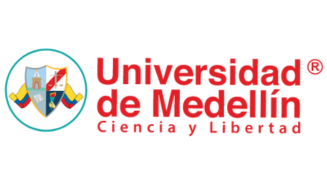

#**Especialización en Ciencia de Datos e Inteligencia Artificial**

#**Aprendizaje automatico:**
#Actividad de clasificación (Regresión Logística)

**Descripción del Proyecto:**
Este cuaderno documenta el desarrollo de un proyecto completo de Machine Learning (fases inicial e intermedia) aplicado a un problema de clasificación mediante Regresión Logística. El propósito principal es construir un modelo predictivo robusto que sirva como herramienta de apoyo en la toma de decisiones.

**Estructura y Entregables**
El trabajo se realiza de manera grupal y la evaluación se divide equitativamente (33.33% cada componente) en tres entregables:

**Memoria Técnica:** Documento formal en formato PDF.

**Notebook Executable:** Código documentado y ejecutable en Google Colab.

**Vídeo de Sustentación:** Presentación ejecutiva del proyecto (duración: 5 a 8 minutos).

**Integrantes:**

* Alejandro Ramirez Marin
* Luis Fernando Betancurt

## 1. Selección y Descripción del Dataset

Para el desarrollo de esta actividad seleccionamos un dataset del sector bancario enfocado en campañas de **Marketing Bancario**, alojado en la plataforma **Kaggle**.

Tras una revisión preliminar, verificamos que la base de datos cumple formalmente con los requisitos definidos para la actividad:

* **Variable objetivo binaria ($y$):** Presencia de una variable a predecir con dos clases posibles.
* **Atributos categóricos:** Variables de tipo texto o categorías.
* **Atributos numéricos en diferentes escalas:** Variables continuas o discretas con distintos rangos de valores.
* **Valores faltantes o nulos:** Presencia de datos incompletos para aplicar técnicas de limpieza e imputación.

---

### Validaciones sobre la Base de Datos

A continuación se detalla cómo se identifican estos parámetros en nuestro dataset (lo cual confirmaremos técnicamente durante la fase de exploración en código):

* **Variable Objetivo Binaria ($y$):**
  * `deposit`: Indica si el cliente suscribió un depósito a término fijo (`yes` / `no`).

* **Variables Categóricas:**
  * `job` (ocupación), `marital` (estado civil), `education` (nivel educativo), `housing` (crédito de vivienda), `loan` (crédito personal), entre otras.

* **Variables Numéricas en Diferentes Escalas:**
  * `age`: Edad del cliente en años (ej. 18 a 90 años).
  * `balance`: Saldo promedio anual en euros (ej. -2,000 a 50,000 EUR).
  * `duration`: Duración de la última llamada en segundos (ej. 0 a 3,000 segundos).
  * `campaign`: Número de contactos realizados durante esta campaña.

* **Valores Faltantes o Nulos:**
  * En este dataset, los valores faltantes están representados bajo la categoría `"unknown"` en columnas como `job`, `education`, `contact` y `poutcome`. Esto nos permitirá aplicar estrategias de imputación y tratamiento de datos en la Fase 2.

> **Fuente del Dataset:** [Kaggle - Bank Marketing Dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset/data)

## 2. Contexto de Negocio

Una institución financiera busca optimizar la eficiencia de sus campañas de telemarketing para la venta de **depósitos a término fijo**. Actualmente, la realización de llamadas de captación masivas y no segmentadas genera elevados costos operativos en los centros de contacto y causa fricción en la experiencia de clientes no interesados.

El objetivo es construir un pipeline de Machine Learning basado en un modelo de **Regresión Logística** para predecir la probabilidad de que un cliente acepte contratar el depósito a término. Esto permitirá segmentar a los prospectos antes de realizar la llamada, focalizando los recursos comerciales en los clientes con mayor propensión de conversión y reduciendo el esfuerzo operativo en aquellos no interesados.

## Carga e Importación de Datos

Para que se haga mas facil la carga del archivo, se creo un repositorio en github, y asi facilitar la ejecución remota sin necesidad de subir archivos manualmente en cada sesión, cargaremos el dataset directamente desde la fuente alojada en el repositorio de **GitHub**.

A continuación, importamos las librerías necesarias y leemos la base de datos `bank.csv`:

In [ ]:
# Codigo para cargar el dataset directmente del repositorio de Github
import pandas as pd

# Enlace RAW del archivo en el repositorio de github
enlace = "https://raw.githubusercontent.com/lufebe05/actividadClasificacionRL/main/bank.csv"

# se carga el dataset en la variable que va a quedar para el analisis

bank = pd.read_csv(enlace, sep=",")

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Exploración Inicial y Verificación de la Información

En esta sección realizamos la inspección preliminar del conjunto de datos para entender su estructura general. El objetivo es identificar las columnas disponibles, comprobar los tipos de datos asignados a cada atributo y detectar inconsistencias o información faltante antes de avanzar al procesamiento de los datos.

In [ ]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
bank.shape

(11162, 17)

### Definición de Variables y Metadatos (Fase 1)

El conjunto de datos contiene **11,162 registros** y **17 variables**, clasificadas de la siguiente manera:

#### 1. Variable Objetivo ($y$)
* **`deposit`**: Indica si el cliente suscribió el depósito a término fijo (`"yes"` / `"no"`).

#### 2. Variables Predictoras ($X$)

* **Atributos Demográficos y Financieros:**
  * `age`: Edad del cliente (*Numérica*).
  * `job`: Tipo de trabajo / ocupación (*Categórica*).
  * `marital`: Estado civil (*Categórica*).
  * `education`: Nivel educativo (*Categórica*).
  * `default`: ¿Tiene crédito en mora/incumplimiento? (*Categórica*).
  * `balance`: Saldo promedio anual en euros (*Numérica*).
  * `housing`: ¿Tiene préstamo de vivienda? (*Categórica*).
  * `loan`: ¿Tiene préstamo personal? (*Categórica*).

* **Atributos del Último Contacto:**
  * `contact`: Tipo de comunicación utilizada (*Categórica*).
  * `day`: Último día del mes en que fue contactado (*Numérica*).
  * `month`: Último mes del año en que fue contactado (*Categórica*).
  * `duration`: Duración de la última llamada en segundos (*Numérica*).

* **Otros Atributos de Campaña:**
  * `campaign`: Número de contactos realizados durante esta campaña para este cliente (*Numérica*).
  * `pdays`: Días transcurridos desde el último contacto de una campaña previa (*Numérica*, `-1` significa que no fue contactado antes).
  * `previous`: Número de contactos realizados antes de esta campaña (*Numérica*).
  * `poutcome`: Resultado de la campaña de marketing anterior (*Categórica*).

In [ ]:
import numpy as np

dfBank = bank.copy()
print(dfBank.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


### **Preprocesamiento y Limpieza — Identificación de Nulos y Duplicados**

En esta fase de exploración inicial de calidad de datos se identifican dos aspectos clave:

1. **Valores Nulos Implícitos (`unknown`):**
   A diferencia de otros conjuntos de datos, en el dataset de Bank Marketing las mediciones faltantes no vienen codificadas como `NaN`, sino con la etiqueta textual `"unknown"` en variables como `job`, `education`, `contact` y `poutcome`. Siguiendo las buenas prácticas vistas en clase, se realiza la conversión explícita de `"unknown"` a `np.nan` para permitir que el transformador `SimpleImputer` dentro del `Pipeline` gestione su imputación de manera automática y prevenga la fuga de datos (*data leakage*).

2. **Registros Duplicados:**
   Se evalúa la presencia de filas idénticas en el conjunto de datos mediante `.duplicated().sum()`.

In [ ]:
dfBank = dfBank.replace("unknown", np.nan)

# con esta conversion, volvemos nuevamente a validar cuantos nulos se tienen en el dataset

print(dfBank.isna().sum())

age             0
job            70
marital         0
education     497
default         0
balance         0
housing         0
loan            0
contact      2346
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     8326
deposit         0
dtype: int64


In [ ]:
#Calcular el porcentaje de valores nulos por categoria
variables_con_nulos = ['job', 'education', 'contact', 'poutcome']
for col in variables_con_nulos:
    null_count = dfBank[col].isnull().sum()
    total_rows = len(dfBank)
    percentage_null = (null_count / total_rows) * 100
    print(f"Variable '{col}': {null_count} nulos ({percentage_null:.2f}%)")

Variable 'job': 70 nulos (0.63%)
Variable 'education': 497 nulos (4.45%)
Variable 'contact': 2346 nulos (21.02%)
Variable 'poutcome': 8326 nulos (74.59%)


**Justificación para Conservar la Variable `poutcome`**

A pesar de que la variable `poutcome` (resultado de la campaña previa) presenta una proporción elevada de valores faltantes/`unknown`, se decidió mantenerla en el dataset por las siguientes razones:

1. **Significado de Negocio:** La categoría `"unknown"` no representa una pérdida de información aleatoria, sino la condición explícita de clientes que no fueron contactados en campañas anteriores.
2. **Alto Poder Predictivo:** Los registros donde `poutcome = "success"` presentan una correlación sumamente alta con la suscripción del depósito a término fijo ($y=1$), convirtiéndola en una de las variables predictoras más relevantes para el modelo.
3. **Tratamiento en el Pipeline:** A través del procesamiento categórico (`SimpleImputer` / `OneHotEncoder`), la condición de falta de historial se codifica como una categoría más, permitiendo al algoritmo aprender diferencias entre clientes recurrentes y clientes nuevos.

#### **Tratamiento e Identificación de Nulos Implícitos**

Al realizar la transformación de la etiqueta categórica `"unknown"` por valores de nulos estándar (`np.nan`), se evidencia que el conjunto de datos efectivamente contiene datos faltantes distribuidos en cuatro variables categóricas:

* **`job`**: 70 valores nulos.
* **`education`**: 497 valores nulos.
* **`contact`**: 2,346 valores nulos.
* **`poutcome`**: 8,326 valores nulos.

**Justificación Técnica:**
Las demás columnas no presentan registros ausentes (`0` nulos). Esta conversión explícita a `np.nan` garantiza cumplir con las exigencias del trabajo, permitiendo que el componente `SimpleImputer` dentro de nuestro `Pipeline` de Scikit-Learn gestione automáticamente la imputación (mediante la estrategia de la moda / valor más frecuente) sin incurrir en fuga de datos (*data leakage*).

In [ ]:
dfBank.duplicated().sum()

np.int64(0)

#### **Verificación de Registros Duplicados**

Al ejecutar la validación de duplicidad mediante `.duplicated().sum()`, se constata la presencia de **0 registros duplicados** en el conjunto de datos.

**Conclusión:**
Dado que cada fila representa una interacción única e independiente con un cliente y no existen registros repetidos, no se requiere aplicar técnicas de eliminación de duplicados, preservando el 100% de la muestra original para el modelado.

## **Estructuración de Variables y Mapeo de la Variable Objetivo**

**1. Mapeo Binario de $y$**
La variable objetivo `deposit` se codifica a formato numérico binario ($1 = \text{Suscribió el depósito}$, $0 = \text{No suscribió}$), permitiendo su procesamiento por el algoritmo de Regresión Logística.

**2. Segmentación de Variables ($X$) por Tipo**
Para aplicar las transformaciones correspondientes dentro del `ColumnTransformer` sin riesgo de mezcla de tipos de datos ni fuga de información, se dividen los predictores en dos grupos:

* **Variables Numéricas (`cols_numericas`):** `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous` (requieren escalado numérico)[cite: 1].
* **Variables Categóricas (`cols_categoricas`):** `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome` (requieren imputación por moda y codificación One-Hot)[cite: 1].

In [ ]:
# La variable objetivo deposit, esta establecida con yes y no, por lo tanto se debe hacer la conversion a 0 y 1
#" yes": 1, "no": 0
dfBank['deposit'] = dfBank['deposit'].map({"yes": 1, "no": 0})
dfBank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,NaN,5,may,1042,1,-1,0,NaN,1
1,56,admin.,married,secondary,no,45,no,no,NaN,5,may,1467,1,-1,0,NaN,1
2,41,technician,married,secondary,no,1270,yes,no,NaN,5,may,1389,1,-1,0,NaN,1
3,55,services,married,secondary,no,2476,yes,no,NaN,5,may,579,1,-1,0,NaN,1
4,54,admin.,married,tertiary,no,184,no,no,NaN,5,may,673,2,-1,0,NaN,1


In [ ]:
X = dfBank.drop(columns= ['deposit']) # asignar a X todas las columnas excepto 'deposit'
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,59,admin.,married,secondary,no,2343,yes,no,NaN,5,may,1042,1,-1,0,NaN
1,56,admin.,married,secondary,no,45,no,no,NaN,5,may,1467,1,-1,0,NaN
2,41,technician,married,secondary,no,1270,yes,no,NaN,5,may,1389,1,-1,0,NaN
3,55,services,married,secondary,no,2476,yes,no,NaN,5,may,579,1,-1,0,NaN
4,54,admin.,married,tertiary,no,184,no,no,NaN,5,may,673,2,-1,0,NaN


In [ ]:
y = dfBank['deposit']
y

,deposit
0,1
1,1
2,1
3,1
4,1
...,...
11157,0
11158,0
11159,0
11160,0


In [ ]:
numericas = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categoricas = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

In [ ]:
# Aca se determina si el dataset esta balanceado o no
print(f"Dimension de X: {X.shape}")
print(f"Dimension de y: {y.shape}")
print(f"\nDistribución absoluta de la variable objetivo:\n{y.value_counts()}")
print(f"\nDistribución porcentual de la variable objetivo:\n{y.value_counts(normalize=True)}")

Dimension de X: (11162, 16)
Dimension de y: (11162,)

Distribución absoluta de la variable objetivo:
deposit
0    5873
1    5289
Name: count, dtype: int64

Distribución porcentual de la variable objetivo:
deposit
0    0.52616
1    0.47384
Name: proportion, dtype: float64


**Separación de Variables y Análisis Inicial**

Con el conjunto de datos cargado, realizamos la preparación inicial de las variables para el proceso de modelado:

* **Separación de características y objetivo:** Asignamos a $X$ la totalidad de las variables predictoras (excluyendo `deposit`), y a $y$ la variable objetivo codificada.
* **Clasificación de atributos:** Identificamos y agrupamos las columnas según su tipo de dato en **variables numéricas** y **variables categóricas** para facilitar su posterior procesamiento.

---

**Dimensiones del Dataset y Distribución de la Variable Objetivo**

Tras realizar la división, verificamos la forma (*shape*) de los conjuntos de datos obtenidos y analizamos la proporción de las clases en la variable objetivo ($y$):

| Clase | Definición | Porcentaje |
| :--- | :--- | :--- |
| **0** | No suscribió el depósito (`no`) | **52.6%** |
| **1** | Sí suscribió el depósito (`yes`) | **47.4%** |

**Conclusión del Análisis de Balanceo**

La variable objetivo presenta una distribución bastante equitativa entre ambas clases. Al no existir un desbalance severo de datos, el modelo podrá aprender de manera equilibrada sobre ambas categorías sin requerir técnicas complejas de rebalanceo (como *oversampling* o *undersampling*).

## División del Dataset y Construcción del Pipeline

Con la variable objetivo ($y$) y las características ($X$) definidas, realizamos la separación inicial del conjunto de datos en **entrenamiento** y **prueba**, previa a cualquier fase de preprocesamiento.

**¿Por qué se dividen los datos antes de preprocesar?**

Dividir la información en este punto es fundamental para evitar la **fuga de datos** (*data leakage*).

Si aplicáramos transformaciones, como la imputación de nulos o la estandarización de escala a todo el dataset antes de la separación, el conjunto de entrenamiento absorbería información estadística perteneciente al conjunto de prueba. Al separar los datos primero, garantizamos que el preprocesamiento se ajuste exclusivamente con la información de entrenamiento, evaluando el modelo de manera limpia y realista con datos que verdaderamente no ha visto.

In [ ]:
# Importamos todas las librerias necesarias para realizar el entrenamiento, el preprocesamiento y las transdormaciones necesarias
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

In [ ]:
# División del dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
# Pipeline para variables numéricas (Imputación por mediana + Escalado estándar)
numPipeline = Pipeline(steps=[
    ('imputador_num', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

In [ ]:
# Pipeline para variables categóricas (Imputación por moda + Codificación One-Hot)
catPipeline = Pipeline(steps=[
    ('imputador_cat', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [ ]:
# Integración del Preprocesamiento mediante ColumnTransformer
preprocesador = ColumnTransformer(transformers=[
    ('num', numPipeline, numericas),
    ('cat', catPipeline, categoricas)
])

In [ ]:
# Pipeline final completo (Preprocesamiento + Modelo de Regresión Logística)
bankPipeline = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('clasificador', LogisticRegression(random_state=42))
])

In [ ]:
bankPipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputador_num',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalador',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputador_cat',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('clasificador', LogisticRegression(random_state=42))])

In [ ]:
y_pred = bankPipeline.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

una vez realizado todo el proceso de division de datos y el preprocesamiento, observamos el Pipeline se ejecuto de manera correcta al tener las variables numericas y categoricas en el Column Transformer, y todo esto conectado directamente al clasificador

## **Predicción e Interpretación Práctica de Casos de Negocio**

A partir del cálculo de probabilidades continuas con `predict_proba()`, se evalúan tres escenarios estratégicos para la toma de decisiones comerciales:

1. **Caso 1: Alta Probabilidad (> 80%) — Priorización Comercial Alta**
   * **Interpretación:** El modelo asigna una certeza elevada de conversión debido a factores clave como una alta duración del último contacto y un historial previo positivo (`poutcome = success`).
   * **Acción de Negocio:** Asignar inmediatamente al equipo comercial senior para realizar la llamada de cierre y ofrecer condiciones preferenciales de tasa de interés para asegurar la captación.

2. **Caso 2: Baja Probabilidad (< 20%) — Descarte Operativo**
   * **Interpretación:** Prospecto con baja propensión, caracterizado por contactos de muy corta duración y sin historial de conversión.
   * **Acción de Negocio:** Omitir la llamada telefónica para ahorrar costos operativos del call center y evitar el desgaste de la marca por contacto no deseado.

3. **Caso 3: Zona de Incertidumbre (48% – 52%) — Estrategia Intermedia**
   * **Interpretación:** El modelo se encuentra indeterminado debido a señales mixtas (ej. buen saldo bancario pero canal de contacto poco efectivo).
   * **Acción de Negocio:** En lugar de realizar una llamada directa inmediata, enviar una campaña automatizada de nutrición digital (vía Email o SMS) para medir la interacción previa del cliente antes de desplegar un asesor comercial.

In [ ]:
# Obtener las probabilidades de pertenecer a la clase 1 (Suscribir depósito)
y_proba = bankPipeline.predict_proba(X_test)[:, 1]

In [ ]:
# Crear un DataFrame de prueba con las probabilidades calculadas
dfTestAnalisis = X_test.copy()
dfTestAnalisis['probabilidad_deposito'] = y_proba
dfTestAnalisis['prediccion'] = y_pred
dfTestAnalisis['real_deposit'] = y_test.values

In [ ]:
# Filtrar los 3 casos específicos requeridos por la guía
casoAlta = dfTestAnalisis[dfTestAnalisis['probabilidad_deposito'] >= 0.80].head(1)
casoBaja = dfTestAnalisis[dfTestAnalisis['probabilidad_deposito'] <= 0.20].head(1)
casoDuda = dfTestAnalisis[(dfTestAnalisis['probabilidad_deposito'] >= 0.48) & (dfTestAnalisis['probabilidad_deposito'] <= 0.52)].head(1)

In [ ]:
# Concatenar para visualización clara
casosSeleccionados = pd.concat([casoAlta, casoBaja, casoDuda])
casosSeleccionados[['age', 'job', 'duration', 'poutcome', 'probabilidad_deposito', 'prediccion', 'real_deposit']]

,age,job,duration,poutcome,probabilidad_deposito,prediccion,real_deposit
2120,56,retired,1064,NaN,0.990750,1,1
7879,35,management,268,NaN,0.114551,0,0
8985,37,technician,561,NaN,0.490938,0,0


## **Interpretación Práctica de los 3 Casos de Negocio Seleccionados**

A partir de la ejecución del `Pipeline` de Regresión Logística y la extracción de probabilidades estimadas (`predict_proba`), se analizaron tres perfiles de clientes específicos del conjunto de prueba:

#### **1. Caso de Alta Probabilidad (~99.08%) — Registro ID 2120**
* **Atributos Clave:** Cliente de 56 años, jubilado (`retired`), con una extensión de contacto destacada (`duration = 1064` segundos).
* **Análisis Técnico:** La extensa duración de la llamada y la condición de jubilado incrementan sustancialmente la probabilidad estimada a un **99.08%** ($p = 0.990750$), asignando una predicción $1$, la cual coincide con la decisión real del cliente (`real_deposit = 1`).
* **Acción Estratégica de Negocio:** Este perfil debe priorizarse para asignación inmediata al equipo comercial. Un contacto prolongado y receptivo en esta población objetivo es un indicador definitivo para cerrar la venta y concretar la captación del depósito a término.

#### **2. Caso de Baja Probabilidad (~11.46%) — Registro ID 7879**
* **Atributos Clave:** Cliente de 35 años, profesional administrativo (`management`), con una duración de llamada corta (`duration = 268` segundos).
* **Análisis Técnico:** La corta interacción telefónica sitúa la probabilidad en apenas **11.46%** ($p = 0.114551$), prediciendo la clase $0$, lo que concuerda plenamente con el resultado real (`real_deposit = 0`).
* **Acción Estratégica de Negocio:** Omitir el contacto telefónico directo para esta tipología de cliente. Su exclusión automatizada de las campañas telefónicas activas optimiza los recursos de la fuerza de ventas y evita saturar a clientes con baja disposición de compra.

#### **3. Caso de Incertidumbre (~49.09%) — Registro ID 8985**
* **Atributos Clave:** Cliente de 37 años, técnico (`technician`), con una interacción intermedia (`duration = 561` segundos).
* **Análisis Técnico:** El modelo calcula una probabilidad de **49.09%** ($p = 0.490938$), ubicándose justo en el umbral de indecisión ($~50\%$). Al estar ligeramente por debajo del límite de corte, el algoritmo predice clase $0$, acertando frente al dato real (`real_deposit = 0`).
* **Acción Estratégica de Negocio:** Ante este nivel de incertidumbre, desplegar una llamada telefónica convencional resulta ineficiente. La estrategia idónea es dirigir a este segmento hacia campañas digitales automatizadas (como correo masivo o mensajes push), permitiendo madurar la intención de compra sin incurrir en costos de gestión comercial directa.